In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 14)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']


In [3]:
# ============================================================
# 3. churn_to_mvno 분석용 데이터 구성
# ============================================================
# churn_to_mvno는 "메이저(1/2/3) -> MVNO(4)"만 1이므로,
# 해석상 전년 통신사가 메이저였던 사람들만 대상으로 보는 것이 자연스럽다.
#
# 단, 현재 저장된 데이터에 telco_tminus1 같은 컬럼이 없다면
# 전체 데이터에서 그대로 진행해야 한다.
# 여기서는 우선 현재 컬럼 기준으로 안전하게 진행한다.

target_col = "churn_to_mvno"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

# 혹시 telco 관련 컬럼이 있으면 누수 방지를 위해 제외
possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols
drop_cols = list(dict.fromkeys(drop_cols))

feature_cols = [col for col in df.columns if col not in drop_cols]

print("사용 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)
print("churn_to_mvno 비율:", df[target_col].mean())
print("양성 개수:", df[target_col].sum())

사용 feature 개수: 7
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']
churn_to_mvno 비율: 0.012470035594082182
양성 개수: 515


In [4]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("양성 비율:", y.mean())
print("고유 pid 수:", groups.nunique())

X shape: (41299, 7)
양성 비율: 0.012470035594082182
고유 pid 수: 10071


In [5]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train 양성 비율:", y_train.mean())
print("Test 양성 비율 :", y_test.mean())
print("Train 양성 개수:", y_train.sum())
print("Test 양성 개수 :", y_test.sum())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))

Train shape: (32992, 7)
Test shape : (8307, 7)
Train 양성 비율: 0.013063773035887488
Test 양성 비율 : 0.010111953773925604
Train 양성 개수: 431
Test 양성 개수 : 84
겹치는 pid 수: 0


In [6]:
# ============================================================
# 6. 평가 함수
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

In [7]:
# ============================================================
# 7. Logistic Regression 학습
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]

In [8]:
# ============================================================
# 8. Random Forest 학습
# ============================================================
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

In [9]:
# ============================================================
# 9. 성능 비교
# ============================================================
result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")

result_df = pd.DataFrame([result_log, result_rf]).sort_values("pr_auc", ascending=False)
display(result_df)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression,0.604189,0.013366,0.523810,0.026066,0.626394,0.018221
1,RandomForest,0.780065,0.012311,0.261905,0.023517,0.557256,0.012097


In [10]:
# ============================================================
# 10. 상세 리포트 확인
# ============================================================
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.9920    0.6050    0.7516      8223
           1     0.0134    0.5238    0.0261        84

    accuracy                         0.6042      8307
   macro avg     0.5027    0.5644    0.3888      8307
weighted avg     0.9821    0.6042    0.7443      8307

Confusion Matrix
[[4975 3248]
 [  40   44]]

===== Random Forest =====
              precision    recall  f1-score   support

           0     0.9905    0.7854    0.8761      8223
           1     0.0123    0.2619    0.0235        84

    accuracy                         0.7801      8307
   macro avg     0.5014    0.5236    0.4498      8307
weighted avg     0.9806    0.7801    0.8675      8307

Confusion Matrix
[[6458 1765]
 [  62   22]]


In [11]:
# ============================================================
# 11. Logistic Regression 계수 확인
# ============================================================
log_model = logistic_pipe.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": log_model.coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

display(coef_df.head(15))

,feature,coef,abs_coef
3,c01002_tminus1,-0.431219,0.431219
1,a03024_tminus1,0.229182,0.229182
5,c02003_tminus1,-0.170805,0.170805
0,a03002_tminus1,-0.166963,0.166963
2,a03026_tminus1,0.091545,0.091545
4,c01004_tminus1,-0.082265,0.082265
6,c02001_tminus1,-0.081596,0.081596


In [12]:
# ============================================================
# 12. Random Forest 중요도 확인
# ============================================================
rf_model = rf_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(15))

,feature,importance
3,c01002_tminus1,0.379363
4,c01004_tminus1,0.180481
0,a03002_tminus1,0.158113
6,c02001_tminus1,0.092092
5,c02003_tminus1,0.066349
2,a03026_tminus1,0.062955
1,a03024_tminus1,0.060648


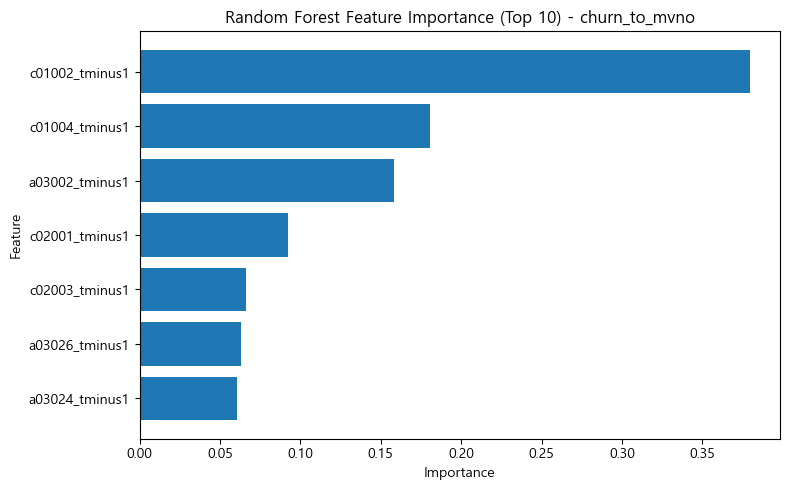

In [13]:
# ============================================================
# 13. 중요 변수 시각화
# ============================================================
top_n = 10

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance"].head(top_n)[::-1]
)
plt.title("Random Forest Feature Importance (Top 10) - churn_to_mvno")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## [ 결과 해석 ]

### 1. `churn_to_mvno` 예측 결과 해석

`churn_to_mvno`는 전체 데이터 중 양성 비율이 약 1.25%에 불과한 매우 희소한 이벤트다.
따라서 이번 실험에서는 단순 정확도보다 실제 MVNO 이동자를 얼마나 잘 탐지했는지가 더 중요하다.
이 점을 고려하면, `PR-AUC`, `Recall`, `Precision` 중심의 해석이 적절하다.

이번 baseline 결과에서는 `LogisticRegression`이 `RandomForest`보다 상대적으로 더 적절한 기준 모델로 확인되었다.
`LogisticRegression`은 `PR-AUC`와 `Recall`에서 더 높은 값을 보였고, 특히 실제 MVNO 이동자를 더 많이 탐지했다는 점에서 의미가 있다.
반면 `RandomForest`는 정확도는 더 높았지만, 이는 극심한 클래스 불균형 상황에서 음성 클래스(0)를 많이 맞춘 결과로 해석할 수 있다.

즉, 이번 실험에서 중요한 것은 전체를 얼마나 많이 맞췄는가보다 드문 양성 사례를 얼마나 찾아냈는가이며, 이 기준에서는 `LogisticRegression`이 더 적합한 baseline으로 판단된다.
다만 이번 결과는 MVNO 이동을 충분히 정확하게 예측했다고 보기보다는, 양성 비율이 매우 낮은 희소 라벨 환경에서 baseline 단계의 한계를 확인한 결과로 해석하는 것이 더 적절하다.
즉, 현재 변수 구성만으로도 일부 신호는 포착되었지만, `churn_to_mvno`는 라벨 자체의 희소성과 제한된 입력 변수로 인해 예측 난도가 매우 높은 문제임을 보여준다.

---

### 2. 모델별 성능 비교

`LogisticRegression`은 실제 양성 사례의 절반 이상을 탐지했다.
이는 MVNO 이동 가능성이 있는 고객을 놓치지 않는 측면에서는 의미 있는 결과다.
다만 Precision이 매우 낮게 나타나, 모델이 양성으로 예측한 사례 중 실제 양성은 극히 일부에 그쳤다.
즉, 양성을 적극적으로 찾으려는 경향은 있었지만 오탐(False Positive)이 매우 많았다.

반면 `RandomForest`는 Accuracy가 더 높았으나, Recall과 `PR-AUC`가 더 낮았다.
이는 전체적으로는 더 안정적으로 보일 수 있지만, 실제로 중요한 MVNO 이동자 탐지 성능은 오히려 떨어졌음을 의미한다.
희소 이벤트 예측에서는 이러한 경우 높은 Accuracy가 반드시 좋은 모델을 뜻하지 않으므로 주의가 필요하다.

결과적으로 이번 실험에서는 `RandomForest`보다 `LogisticRegression`이 더 많은 양성 사례를 포착했고, 희소 클래스 탐지라는 목적에도 더 부합하는 성능을 보였다.

---

### 3. Confusion Matrix 해석

`LogisticRegression`은 실제 MVNO 이동자를 상대적으로 많이 찾아냈지만, 그 과정에서 음성을 양성으로 잘못 분류한 사례도 매우 많았다.
즉, 놓치지 않으려는 성향은 강했지만 그만큼 오탐 비용이 큰 모델이라고 볼 수 있다.

반면 `RandomForest`는 음성을 음성으로 유지하는 데는 상대적으로 유리했지만, 실제 양성을 더 많이 놓쳤다.
즉, 보수적으로 예측하면서 Accuracy는 확보했지만, 정작 중요한 MVNO 이동 탐지에서는 한계를 보였다.

이러한 차이는 두 모델의 성향 차이로 이해할 수 있다.
`LogisticRegression`은 양성을 더 적극적으로 탐지하는 방향,
`RandomForest`는 전체 오분류를 줄이는 방향으로 작동한 것으로 볼 수 있다.

---

### 4. 변수 중요도 해석

두 모델 모두 공통적으로 `c01002_tminus1`를 중요한 변수로 평가했다.
이는 해당 변수가 MVNO 이동 여부를 설명하는 데 상대적으로 강한 신호를 가질 가능성을 보여준다.

또한 `c01004_tminus1`, `a03002_tminus1` 역시 주요 변수로 반복적으로 확인되었다.
즉, 현재 baseline 기준에서는 일부 핵심 변수들이 두 모델에서 일관되게 중요하게 나타났고, 이 변수들이 향후 해석 및 추가 분석의 중심이 될 수 있다.

다만 현재 단계의 변수 중요도는 어디까지나 예측 관점에서의 상대적 기여도를 의미한다.
따라서 이를 곧바로 인과 관계로 해석하기보다는, 예측에 유용한 신호를 제공한 변수 수준에서 이해하는 것이 적절하다.

---

### 5. 종합 정리

이번 `churn_to_mvno` baseline 실험은 극심한 클래스 불균형 환경에서 수행되었으며, 전체적으로 예측 난도가 매우 높은 문제임이 확인되었다.
그럼에도 불구하고 `LogisticRegression`은 `RandomForest`보다 더 높은 `PR-AUC`와 `Recall`을 보여, 희소한 양성 사례를 탐지하는 기준 모델로서 더 적절한 결과를 보였다.

다만 Precision이 매우 낮아 오탐이 많았고, 전반적인 예측 성능도 아직 실무적으로 활용하기에는 제한적이다.
즉, 현재 결과는 MVNO 이동 예측이 충분히 가능하다고 보기보다는, 제한된 변수만으로도 일부 신호는 포착되지만 성능 개선 여지가 매우 크다는 점을 보여주는 baseline 결과로 해석하는 것이 적절하다.

향후에는 변수 확장, threshold 조정, 불균형 대응 기법 적용 등을 통해 성능을 개선할 필요가 있다.

---

## [ 요약 ]

> `churn_to_mvno`는 양성 비율이 약 1.25%에 불과한 극심한 불균형 문제로, 정확도보다 `PR-AUC`, `Recall`, `Precision` 중심의 해석이 필요하다.

> baseline 비교 결과, `LogisticRegression`은 `RandomForest`보다 더 높은 `PR-AUC`와 `Recall`을 보여 희소한 MVNO 이동자를 탐지하는 기준 모델로 더 적절한 성능을 보였다.

> 다만 Precision은 매우 낮아 오탐이 많았으며, 전반적인 예측 성능 역시 제한적이어서 향후 feature 확장과 불균형 대응 기법 적용이 필요하다.